# 03 - Poisson Goals Model

Fit per-team attack and defense strengths, visualize them, draw a scoreline heatmap for a fixture, and backtest both models.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

import numpy as np
from wcpredictor.data import load_matches, load_teams
from wcpredictor.data.preprocess import build_training_matches
from wcpredictor.models import EloModel, PoissonModel
from wcpredictor.evaluation import backtest

In [2]:
tr = build_training_matches(load_matches(config), config)
teams = load_teams(config)
poisson = PoissonModel(config).fit(tr)
strengths = poisson.strengths_table(teams)
print('home advantage factor:', round(np.exp(poisson.home_advantage), 3))
strengths.head(15)

home advantage factor: 1.207


,team,attack,defense,net_strength,confederation,pot
0,France,0.667964,0.584588,1.252551,UEFA,1.0
1,Spain,0.561546,0.596431,1.157976,UEFA,1.0
2,Netherlands,0.647161,0.498397,1.145558,UEFA,1.0
3,Colombia,0.173920,0.882708,1.056628,CONMEBOL,1.0
4,Germany,0.677691,0.343772,1.021463,UEFA,1.0
5,Brazil,0.465839,0.528370,0.994209,CONMEBOL,1.0
6,England,0.539848,0.369726,0.909574,UEFA,1.0
7,Argentina,0.529955,0.359408,0.889363,CONMEBOL,1.0
8,Belgium,0.374265,0.495501,0.869766,UEFA,2.0
9,Portugal,0.530048,0.329819,0.859867,UEFA,1.0


## Dixon-Coles correction

In [3]:
print("Fitted Dixon-Coles rho:", round(poisson.rho, 4))

Fitted Dixon-Coles rho: -0.0948


In [4]:
from dataclasses import replace
config_indep = config.with_overrides(poisson=replace(config.poisson, dixon_coles=False))
poisson_indep = PoissonModel(config_indep).fit(tr)
m_dc = poisson.scoreline_matrix('France', 'Morocco', True)
m_indep = poisson_indep.scoreline_matrix('France', 'Morocco', True)
print(f'P(0-0): Dixon-Coles {m_dc[0,0]:.4f}  vs  independent {m_indep[0,0]:.4f}')
print(f'P(1-1): Dixon-Coles {m_dc[1,1]:.4f}  vs  independent {m_indep[1,1]:.4f}')

P(0-0): Dixon-Coles 0.1400  vs  independent 0.1278
P(1-1): Dixon-Coles 0.1412  vs  independent 0.1290


With a fitted ρ < 0 (as here), the Dixon-Coles correction pulls probability mass *toward* the low-scoring draws 0-0 and 1-1 and *away* from the 1-0/0-1 scorelines, relative to the independent Poisson model — the classic finding that plain independent Poisson underestimates low-scoring draws.

## Attack vs defense

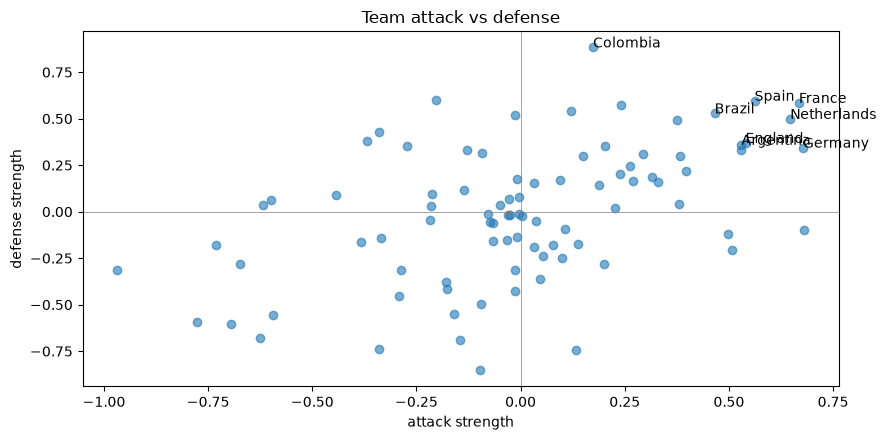

In [5]:
fig, ax = plt.subplots()
ax.scatter(strengths['attack'], strengths['defense'], alpha=0.6)
for _, r in strengths.head(8).iterrows():
    ax.annotate(r['team'], (r['attack'], r['defense']))
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('attack strength'); ax.set_ylabel('defense strength')
ax.set_title('Team attack vs defense'); plt.tight_layout(); plt.show()

## Scoreline probabilities for a fixture

The annotated heatmap tints each scoreline by who it favours (blue = home win, grey = draw, red = away win) and rings the most likely score in gold.

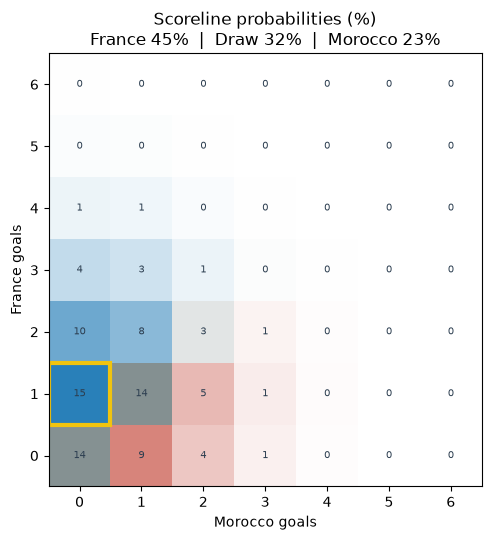

In [6]:
from wcpredictor.visualization import (plot_scoreline_heatmap,
                                       plot_match_comparison)
plot_scoreline_heatmap(poisson, 'France', 'Morocco', neutral=True)
plt.tight_layout(); plt.show()

## Match outcome: Elo vs Poisson

Compare the win/draw/loss probabilities the two models assign to the same fixture.

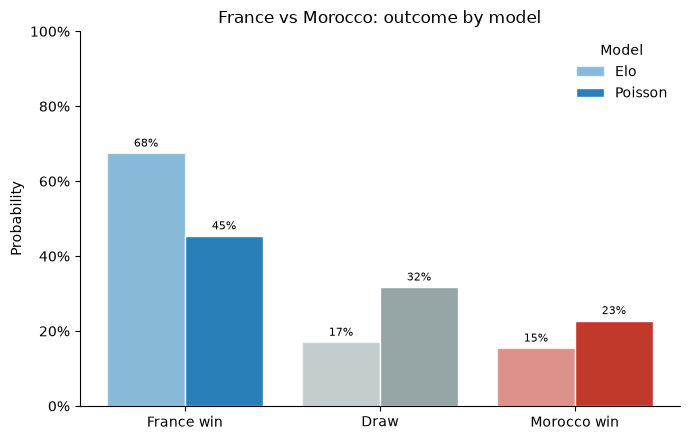

In [7]:
elo = EloModel(config).fit(tr)
home, away = 'France', 'Morocco'
preds = {'Elo': elo.predict_match(home, away, True),
         'Poisson': poisson.predict_match(home, away, True)}
plot_match_comparison(preds, home, away)
plt.tight_layout(); plt.show()

## Backtest: Elo vs Poisson

Walk-forward evaluation. Lower log-loss / RPS is better.

In [8]:
from wcpredictor.evaluation import backtest, DEFAULT_MIN_TRAIN, calibration_table
elo_res = backtest(lambda: EloModel(config), tr, config, min_train=DEFAULT_MIN_TRAIN, collect_predictions=True)
poi_res = backtest(lambda: PoissonModel(config), tr, config, min_train=DEFAULT_MIN_TRAIN, collect_predictions=True)
pd.DataFrame([dict(model='Elo', **elo_res.as_dict()),
              dict(model='Poisson', **poi_res.as_dict())])

,model,accuracy,log_loss,rps,n_matches
0,Elo,0.502632,1.026549,0.204887,760
1,Poisson,0.523684,1.020670,0.205235,760


## Calibration

Reliability diagram: a well-calibrated model's points sit on the diagonal.

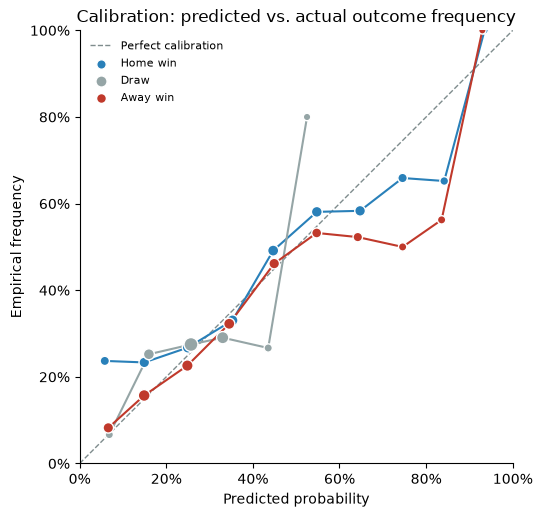

In [9]:
calib = calibration_table(poi_res.predictions)
from wcpredictor.visualization import plot_calibration
plot_calibration(calib)
plt.tight_layout(); plt.show()

## Model comparison

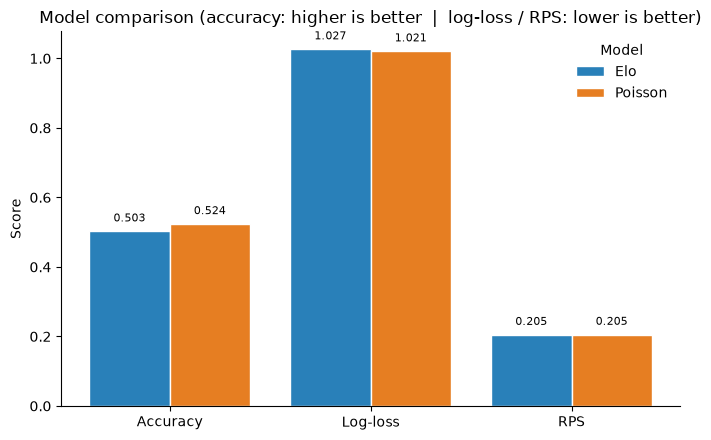

In [10]:
from wcpredictor.visualization import plot_model_comparison
plot_model_comparison({'Elo': elo_res, 'Poisson': poi_res})
plt.tight_layout(); plt.show()